In [1]:
import geopandas as gpd
from owslib.wfs import WebFeatureService
from io import BytesIO
import folium

In [3]:
url = "http://www.ideandalucia.es/services/DERA_g9_transport_com/wfs?service=wfs&request=getcapabilities"

wfs = WebFeatureService(url=url, version="2.0.0")

# Ver capas disponibles
list(wfs.contents)

# Elegir una capa
layer = "DERA_g9_transport_com:g09_01_Puerto_pun"

# Descargar datos
response = wfs.getfeature(typename=layer, outputFormat="application/json")
data = BytesIO(response.read())

gdf = gpd.read_file(data)
gdf.head()

,id,id_dera,id_puerto,id_areamar,nombre,pesquero,deportivo,comercial,geometry
0,g09_01_Puerto_pun.10906400000001,10906400000001,110270000010,110270000010,Puerto de Cádiz,No,Sí,No,MULTIPOINT ((209003.876 4053187.431))
1,g09_01_Puerto_pun.10906400000002,10906400000002,290940000010,290940000010,Puerto de la Caleta de Vélez,No,Sí,No,MULTIPOINT ((404923.387 4067416.079))
2,g09_01_Puerto_pun.10906400000003,10906400000003,110280000017,110280000017,Puerto de Cádiz,No,No,Sí,MULTIPOINT ((209550.026 4046446.84))
3,g09_01_Puerto_pun.10906400000004,10906400000004,110300000018,110300000018,Puerto Deportivo de Rota,No,Sí,No,MULTIPOINT ((199821.385 4057570.492))
4,g09_01_Puerto_pun.10906400000005,10906400000005,290690000011,290690000011,Puerto Deportivo de Marbella,No,Sí,No,MULTIPOINT ((330909.453 4041688.823))


In [4]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   id          72 non-null     object  
 1   id_dera     72 non-null     int64   
 2   id_puerto   72 non-null     int64   
 3   id_areamar  72 non-null     int64   
 4   nombre      72 non-null     object  
 5   pesquero    72 non-null     object  
 6   deportivo   72 non-null     object  
 7   comercial   72 non-null     object  
 8   geometry    72 non-null     geometry
dtypes: geometry(1), int64(3), object(5)
memory usage: 5.2+ KB


In [5]:
from owslib.wfs import WebFeatureService

url = "http://www.ideandalucia.es/services/DERA_g9_transport_com/wfs?service=wfs&request=getcapabilities"

wfs = WebFeatureService(url=url, version="2.0.0")

for name in wfs.contents:
    print(name)

DERA_g9_transport_com:g09_01_Puerto_pol
DERA_g9_transport_com:g09_01_Puerto_pun
DERA_g9_transport_com:g09_02_Aeropuerto_pol
DERA_g9_transport_com:g09_02_Aeropuerto_pun
DERA_g9_transport_com:g09_03_Helipuerto
DERA_g9_transport_com:g09_04_Itv
DERA_g9_transport_com:g09_05_Peaje
DERA_g9_transport_com:g09_06_AreaServicio
DERA_g9_transport_com:g09_07_Gasolinera
DERA_g9_transport_com:g09_08_EstacionAutobus
DERA_g9_transport_com:g09_09_ParadaAutobus
DERA_g9_transport_com:g09_10_EstacionTren
DERA_g9_transport_com:g09_11_EstacionMetro
DERA_g9_transport_com:g09_12_Faro
DERA_g9_transport_com:g09_13_LineaMetro
DERA_g9_transport_com:g09_14_RedCarreteras
DERA_g9_transport_com:g09_15_ViarioUrbano
DERA_g9_transport_com:g09_17_PuntoKilometrico
DERA_g9_transport_com:g09_18_RedAforos
DERA_g9_transport_com:g09_19_Camino
DERA_g9_transport_com:g09_20_Sendero
DERA_g9_transport_com:g09_21_Ferrocarril
DERA_g9_transport_com:g09_22_ViasPecuarias
DERA_g9_transport_com:g09_23_CarrilBici
DERA_g9_transport_com:g09_24

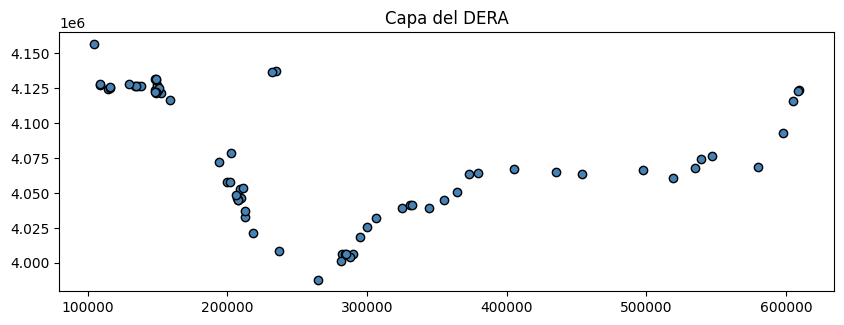

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color="steelblue", edgecolor="black")
plt.title("Capa del DERA")
plt.show()

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\rocio\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


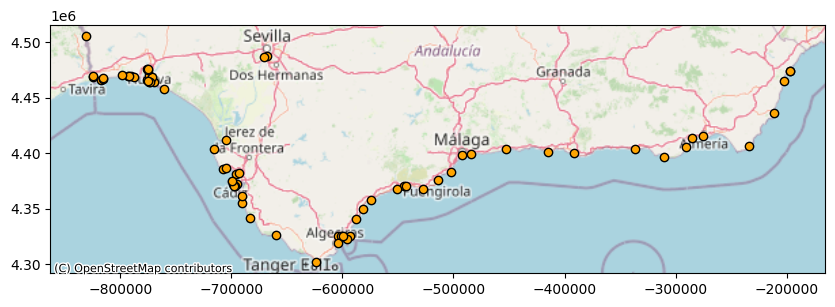

In [7]:
!pip install contextily

import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 10))
gdf.to_crs(epsg=3857).plot(ax=ax, color="orange", edgecolor="black")

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
plt.show()

mapas con folium 
https://python-visualization.github.io/folium/latest/

In [4]:
m = folium.Map(location=(45.5236, -122.6750))
m

In [4]:
#save as html
m.save("index.html")

añadir marcadores

In [3]:
m = folium.Map([45.35, -121.6972], zoom_start=12)

folium.Marker(
    location=[45.3288, -121.6625],
    tooltip="Click me!",
    popup="Mt. Hood Meadows",
    icon=folium.Icon(icon="cloud"),
).add_to(m)

folium.Marker(
    location=[45.3311, -121.7113],
    tooltip="Click me!",
    popup="Timberline Lodge",
    icon=folium.Icon(color="green"),
).add_to(m)

m

crear mapas con vectores

In [3]:
m = folium.Map(location=[-71.38, -73.9], zoom_start=11)

trail_coordinates = [
    (-71.351871840295871, -73.655963711222626),
    (-71.374144382613707, -73.719861619751498),
    (-71.391042575973145, -73.784922248007007),
    (-71.400964450973134, -73.851042243124397),
    (-71.402411391077322, -74.050048183880477),
]

folium.PolyLine(trail_coordinates, tooltip="Coast").add_to(m)

m

You can group multiple elements such as markers together in a FeatureGroup. You can select which you want to show by adding a LayerControl to the map.

In [4]:
m = folium.Map((0, 0), zoom_start=7)

group_1 = folium.FeatureGroup("first group").add_to(m)
folium.Marker((0, 0), icon=folium.Icon("red")).add_to(group_1)
folium.Marker((1, 0), icon=folium.Icon("red")).add_to(group_1)

group_2 = folium.FeatureGroup("second group").add_to(m)
folium.Marker((0, 1), icon=folium.Icon("green")).add_to(group_2)

folium.LayerControl().add_to(m)

m

GeoJSON/TopoJSON overlays
Folium supports both GeoJSON and TopoJSON data in various formats, such as urls, file paths and dictionaries.

In [5]:
import requests

m = folium.Map(tiles="cartodbpositron")

geojson_data = requests.get(
    "https://raw.githubusercontent.com/python-visualization/folium-example-data/main/world_countries.json"
).json()

folium.GeoJson(geojson_data, name="hello world").add_to(m)

folium.LayerControl().add_to(m)

m

Choropleth can be created by binding the data between Pandas DataFrames/Series and Geo/TopoJSON geometries.

In [6]:
import pandas

state_geo = requests.get(
    "https://raw.githubusercontent.com/python-visualization/folium-example-data/main/us_states.json"
).json()
state_data = pandas.read_csv(
    "https://raw.githubusercontent.com/python-visualization/folium-example-data/main/us_unemployment_oct_2012.csv"
)

m = folium.Map(location=[48, -102], zoom_start=3)

folium.Choropleth(
    geo_data=state_geo,
    name="choropleth",
    data=state_data,
    columns=["State", "Unemployment"],
    key_on="feature.id",
    fill_color="YlGn",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Unemployment Rate (%)",
).add_to(m)

folium.LayerControl().add_to(m)

m

unir los puntos de wfs al mapa de folium

In [3]:
import pandas as pd
import folium
import requests

# 1. Pedir los datos al WFS
url = "http://www.ideandalucia.es/services/DERA_g13_limites_administrativos/wfs?service=WFS&request=GetCapabilities"
params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typeName": "namespace:capa",
    "outputFormat": "application/json"  # pedir GeoJSON directamente
}

response = requests.get(url, params=params)
geojson_data = response.json()

# 2. Añadir al mapa
m = folium.Map(location=[40.4, -3.7], zoom_start=10)
folium.GeoJson(geojson_data).add_to(m)

m.save("mapa.html")

AttributeError: partially initialized module 'pandas' from 'C:\Users\rocio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\__init__.py' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)